
Found 368 T1 files
17-32-41_QubitT1_versus_time.hdf5
17-33-46_QubitT1_versus_time.hdf5
17-34-49_QubitT1_versus_time.hdf5
17-35-53_QubitT1_versus_time.hdf5
17-36-57_QubitT1_versus_time.hdf5
17-38-01_QubitT1_versus_time.hdf5
17-39-05_QubitT1_versus_time.hdf5
17-40-08_QubitT1_versus_time.hdf5
17-41-12_QubitT1_versus_time.hdf5
17-42-16_QubitT1_versus_time.hdf5
17-43-19_QubitT1_versus_time.hdf5
17-44-24_QubitT1_versus_time.hdf5
17-59-43_QubitT1_versus_time.hdf5
18-00-36_QubitT1_versus_time.hdf5
18-01-28_QubitT1_versus_time.hdf5
18-02-20_QubitT1_versus_time.hdf5
18-03-12_QubitT1_versus_time.hdf5
18-04-04_QubitT1_versus_time.hdf5
18-04-56_QubitT1_versus_time.hdf5
18-05-48_QubitT1_versus_time.hdf5
18-06-41_QubitT1_versus_time.hdf5
18-07-33_QubitT1_versus_time.hdf5
18-08-25_QubitT1_versus_time.hdf5
18-09-17_QubitT1_versus_time.hdf5
18-10-09_QubitT1_versus_time.hdf5
18-11-01_QubitT1_versus_time.hdf5
18-11-53_QubitT1_versus_time.hdf5
18-12-45_QubitT1_versus_time.hdf5
18-13-37_QubitT1_versus_time

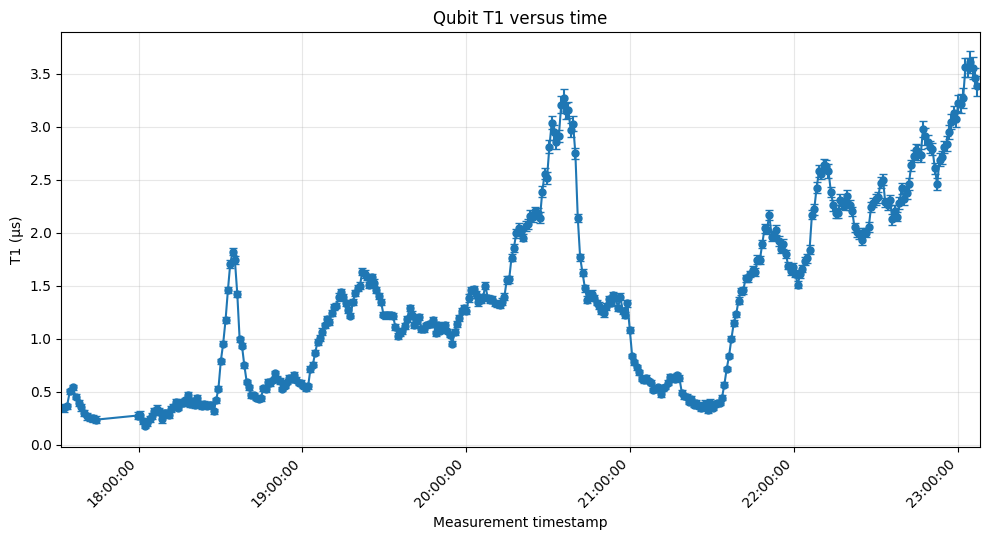

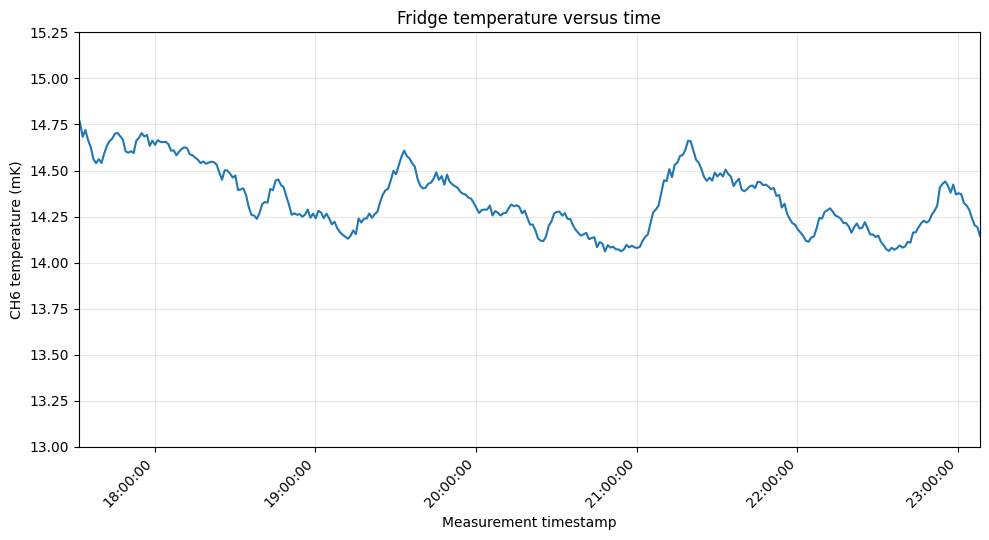


T1 - FRIDGE TEMPERATURE CORRELATION
Pearson r = -0.55947
Matched T1 points = 368


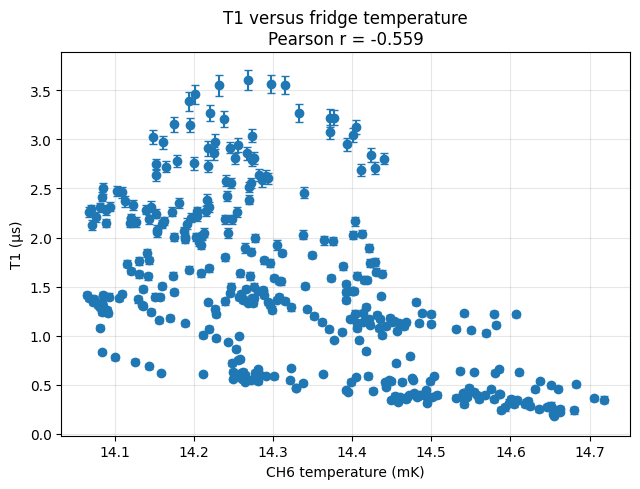


Saved results to:
C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\QubitT1_versus_time_T1_results.npz


In [4]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit
from datetime import datetime

# ==========================================================
# USER SETTINGS
# ==========================================================

build_npz_from_hdf5 = True
load_npz_for_analysis = True

batches = [
    {
        "date": "2026-08-08",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-08",
        "time": ((17, 32), (23, 8)),
    },
]

file_key = "QubitT1_versus_time"

# Choose "I", "Q", or "MAG"
plot_data = "MAG"

# None = automatically find the sweep/time axis
y_key = None

# Usually I/Q/MAG should NOT have their mean subtracted for T1 fitting.
# Set False unless you specifically need it.
subtract_mean = False

x_label = "Delay time"
y_label = "Signal"

show_individual_plots = False

# Fridge temperature log
# Format:
#     DD-MM-YY,HH:MM:SS,temperature_in_K
fridge_log_path = (
    r"C:\Users\qcrew\Desktop\Juncheng\victoria"
    r"\scripts\plot\data_plot_data\CH6 T 26-08-08.log"
)

# Plot temperature in mK for easier comparison with T1.
temperature_scale = 1e3
temperature_unit = "mK"

# Also plot T1 directly versus interpolated fridge temperature.
show_temperature_correlation_plot = True

output_folder = (
    r"C:\Users\qcrew\Desktop\Juncheng\victoria"
    r"\scripts\plot\data_plot_data"
)
os.makedirs(output_folder, exist_ok=True)

# ==========================================================
# FIT SETTINGS
# ==========================================================

# Initial fit guesses
# Set to a number in seconds to force a fixed starting guess.
# Keep None to estimate T1 automatically from each trace.
initial_T1 = None
initial_offset = None


def guess_T1(t, y):
    """Robust initial guess for y = A*exp(-t/T1) + C.

    The estimate uses robust medians at the beginning/end of the trace,
    then looks for the first 1/e crossing. If the trace does not reach
    1/e, it falls back to a log-linear estimate and finally to a fraction
    of the measured time span. Works for both upward and downward decays.
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(t) < 3:
        raise ValueError("Need at least 3 points for a T1 guess.")

    # Work relative to the first fitted delay.
    t_rel = t - t[0]
    span = t_rel[-1] - t_rel[0]
    if span <= 0:
        raise ValueError("T1 delay axis must span a positive range.")

    # Median is less sensitive than mean to noisy points/outliers.
    n_edge = max(3, min(10, len(y) // 5))
    y_start = np.median(y[:n_edge])
    C0 = np.median(y[-n_edge:])
    A_start = y_start - C0

    # If start/end medians happen to be too similar, use the full range.
    signal_range = np.ptp(y)
    if abs(A_start) < max(1e-15, 0.05 * signal_range):
        if abs(y[0] - C0) >= abs(y[-1] - C0):
            A_start = y[0] - C0
        else:
            A_start = (np.max(y) - C0) if abs(np.max(y) - C0) >= abs(np.min(y) - C0) else (np.min(y) - C0)

    # Normalize so an ideal decay starts near 1 and approaches 0.
    T1_guess = np.nan
    if abs(A_start) > 1e-15:
        z = (y - C0) / A_start

        # A tiny moving-average smooth suppresses a single noisy point
        # from creating a false 1/e crossing.
        if len(z) >= 7:
            z_search = np.convolve(z, np.ones(3) / 3.0, mode="same")
            z_search[0] = z[0]
            z_search[-1] = z[-1]
        else:
            z_search = z

        target = 1.0 / np.e
        crossing = np.where(
            (z_search[:-1] >= target) & (z_search[1:] <= target)
        )[0]

        if len(crossing) > 0:
            i = crossing[0]
            z1, z2 = z_search[i], z_search[i + 1]
            t1, t2 = t_rel[i], t_rel[i + 1]
            if z2 != z1:
                frac = (target - z1) / (z2 - z1)
                T1_guess = t1 + frac * (t2 - t1)
            else:
                T1_guess = t1

        # If the measured window does not contain the 1/e point, estimate
        # T1 from the slope of log(normalized signal).
        if not np.isfinite(T1_guess) or T1_guess <= 0:
            mask = np.isfinite(z) & (z > 0.05) & (z < 0.95)
            if np.count_nonzero(mask) >= 3:
                slope, _ = np.polyfit(t_rel[mask], np.log(z[mask]), 1)
                if slope < 0:
                    T1_guess = -1.0 / slope

    # Safe fallback if the trace is very flat/noisy.
    if not np.isfinite(T1_guess) or T1_guess <= 0:
        T1_guess = span / 3.0

    # Keep curve_fit's p0 safely inside the allowed T1 interval.
    eps = 1e-6
    T1_guess = np.clip(
        T1_guess,
        T1_min * (1.0 + eps),
        T1_max * (1.0 - eps),
    )

    # exp_decay uses absolute t, so convert the amplitude at t[0] to the
    # model's A parameter. This also works when the first delay is nonzero.
    A0 = A_start * np.exp(t[0] / T1_guess)

    return A0, T1_guess, C0

# Only use points above this fraction of the maximum delay.
# Set to 0 and 1 to use all data.
fit_start_fraction = 0.0
fit_end_fraction = 1.0

# Remove bad fitted T1 values
remove_outliers = True

# Reasonable T1 range
T1_min = 0.1e-6
T1_max = 1e-3


# ==========================================================
# LOAD FRIDGE TEMPERATURE LOG
# ==========================================================

def load_fridge_temperature(filename):
    """
    Load CH6 fridge-temperature log.

    Expected row format:
        DD-MM-YY,HH:MM:SS,temperature_in_K

    Example:
        08-08-26,17:32:09,1.475900e-02
    """

    if not os.path.exists(filename):
        raise FileNotFoundError(
            f"Fridge temperature log not found: {filename}"
        )

    timestamps = []
    temperatures_K = []

    with open(filename, "r", encoding="utf-8", errors="ignore") as f:

        for line_number, line in enumerate(f, start=1):

            line = line.strip()

            if not line:
                continue

            parts = [part.strip() for part in line.split(",")]

            if len(parts) < 3:
                continue

            try:
                timestamp = datetime.strptime(
                    f"{parts[0]} {parts[1]}",
                    "%d-%m-%y %H:%M:%S"
                )

                temperature_K = float(parts[2])

            except (ValueError, TypeError):
                print(
                    f"Skipping unreadable fridge-log line "
                    f"{line_number}: {line}"
                )
                continue

            if np.isfinite(temperature_K):
                timestamps.append(timestamp)
                temperatures_K.append(temperature_K)

    if len(timestamps) == 0:
        raise ValueError(
            "No valid temperature points found in fridge log."
        )

    timestamps = np.array(timestamps, dtype=object)
    temperatures_K = np.array(temperatures_K, dtype=float)

    order = np.argsort(timestamps)

    timestamps = timestamps[order]
    temperatures_K = temperatures_K[order]

    print(
        f"Loaded {len(timestamps)} fridge-temperature points"
    )

    print(
        "Temperature-log range: "
        f"{timestamps[0].strftime('%Y-%m-%d %H:%M:%S')} -> "
        f"{timestamps[-1].strftime('%Y-%m-%d %H:%M:%S')}"
    )

    return timestamps, temperatures_K


# ==========================================================
# FILE / TIME FUNCTIONS
# ==========================================================

def extract_time(filename):
    """
    Extract HH-MM-SS from filename such as:

    17-32-41_QubitT1_versus_time.hdf5

    Returns:
        (17, 32, 41)
    """
    try:
        name = os.path.basename(filename)
        parts = name.split("-")

        hour = int(parts[0])
        minute = int(parts[1])
        second = int(parts[2].split("_")[0])

        return hour, minute, second

    except Exception:
        return -1, -1, -1


def get_filtered_files(folder, start_time, end_time, file_key):

    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []

    files = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.endswith(".hdf5") and file_key in f
    ]

    def time_tuple(filename):
        h, m, s = extract_time(filename)
        return h, m, s

    filtered = []

    for f in files:

        h, m, s = time_tuple(f)

        if h < 0:
            continue

        file_time = (h, m)

        if start_time <= file_time <= end_time:
            filtered.append(f)

    return sorted(filtered, key=time_tuple)


# ==========================================================
# INSPECT HDF5 STRUCTURE
# ==========================================================

def print_hdf5_structure(filename):

    print("\n" + "=" * 70)
    print("HDF5 FILE:")
    print(os.path.basename(filename))
    print("=" * 70)

    with h5py.File(filename, "r") as f:

        print("Datasets:")

        for key in f.keys():

            obj = f[key]

            if isinstance(obj, h5py.Dataset):
                print(
                    f"  {key:25s} "
                    f"shape={obj.shape} "
                    f"dtype={obj.dtype}"
                )

    print("=" * 70)


# ==========================================================
# LOAD ONE T1 FILE
# ==========================================================

def load_one_hdf5(filename, y_key=None):

    with h5py.File(filename, "r") as f:

        keys = list(f.keys())

        print(f"\nLoading: {os.path.basename(filename)}")
        print("Keys:", keys)

        # --------------------------------------------------
        # Find delay-time axis
        # --------------------------------------------------

        if y_key is not None:

            if y_key not in f:
                raise KeyError(
                    f"y_key='{y_key}' not found in {filename}"
                )

            time_axis = np.asarray(f[y_key][()])

        else:

            # Try common names first
            possible_time_keys = [
                "time",
                "Time",
                "delay",
                "Delay",
                "tau",
                "Tau",
                "x",
                "X",
                "t",
                "T",
            ]

            found_key = None

            for candidate in possible_time_keys:

                if candidate in f:

                    arr = np.asarray(f[candidate][()])

                    if arr.ndim == 1:
                        found_key = candidate
                        break

            # If not found, look for a 1D dataset that is not I/Q/Magnitude
            if found_key is None:

                excluded = {
                    "I",
                    "Q",
                    "Magnitude",
                    "MAG",
                }

                for key in keys:

                    if key in excluded:
                        continue

                    arr = np.asarray(f[key][()])

                    if arr.ndim == 1:
                        found_key = key
                        break

            if found_key is None:

                raise ValueError(
                    "Could not automatically find the T1 delay-time axis.\n"
                    f"Available keys: {keys}\n"
                    "Set y_key manually."
                )

            time_axis = np.asarray(f[found_key][()])

            print(f"Using '{found_key}' as delay-time axis.")

        # --------------------------------------------------
        # Load signal
        # --------------------------------------------------

        if plot_data == "I":

            if "I" not in f:
                raise KeyError("I dataset not found.")

            signal = np.asarray(f["I"][()])

        elif plot_data == "Q":

            if "Q" not in f:
                raise KeyError("Q dataset not found.")

            signal = np.asarray(f["Q"][()])

        elif plot_data == "MAG":

            if "Magnitude" in f:

                signal = np.asarray(f["Magnitude"][()])

            elif "MAG" in f:

                signal = np.asarray(f["MAG"][()])

            elif "I" in f and "Q" in f:

                I = np.asarray(f["I"][()])
                Q = np.asarray(f["Q"][()])

                signal = np.sqrt(I**2 + Q**2)

            else:

                raise KeyError(
                    "Could not find Magnitude, MAG, or I/Q."
                )

        else:

            raise ValueError(
                "plot_data must be 'I', 'Q', or 'MAG'"
            )

        # --------------------------------------------------
        # Average repeated measurements if necessary
        # --------------------------------------------------

        if signal.ndim > 1:

            # Assume last axis corresponds to delay
            signal = np.mean(signal, axis=0)

        signal = np.asarray(signal).squeeze()

        time_axis = np.asarray(time_axis).squeeze()

        # --------------------------------------------------
        # Check dimensions
        # --------------------------------------------------

        print("Time shape:", time_axis.shape)
        print("Signal shape:", signal.shape)

        if len(time_axis) != len(signal):

            raise ValueError(
                f"Time axis length ({len(time_axis)}) "
                f"does not match signal length ({len(signal)})."
            )

        # --------------------------------------------------
        # Remove NaN / inf
        # --------------------------------------------------

        valid = (
            np.isfinite(time_axis)
            & np.isfinite(signal)
        )

        time_axis = time_axis[valid]
        signal = signal[valid]

        # Sort by delay time
        order = np.argsort(time_axis)

        time_axis = time_axis[order]
        signal = signal[order]

        # --------------------------------------------------
        # Optional mean subtraction
        # --------------------------------------------------

        if subtract_mean:

            signal = signal - np.mean(signal)

        return time_axis, signal


# ==========================================================
# EXPONENTIAL FIT
# ==========================================================

def exp_decay(t, A, T1, C):

    return A * np.exp(-t / T1) + C


def fit_T1(t, signal):

    # ------------------------------------------------------
    # Convert time to seconds if necessary
    # ------------------------------------------------------

    t = np.asarray(t, dtype=float)
    signal = np.asarray(signal, dtype=float)

    # Heuristic:
    # If values look like ns/us, convert appropriately.
    #
    # IMPORTANT:
    # Change this if your HDF5 time unit is known.

    t_max = np.max(np.abs(t))

    if t_max > 1:

        # likely ns
        t_sec = t * 1e-9
        time_unit = "ns"

    elif t_max > 1e-3:

        # likely us
        t_sec = t * 1e-6
        time_unit = "us"

    else:

        # assume seconds
        t_sec = t
        time_unit = "s"

    # ------------------------------------------------------
    # Select fit region
    # ------------------------------------------------------

    t_min = np.min(t_sec)
    t_max_sec = np.max(t_sec)

    fit_mask = (
        (t_sec >= t_min +
         fit_start_fraction * (t_max_sec - t_min))
        &
        (t_sec <= t_min +
         fit_end_fraction * (t_max_sec - t_min))
    )

    t_fit = t_sec[fit_mask]
    y_fit = signal[fit_mask]

    # ------------------------------------------------------
    # Initial guesses
    # ------------------------------------------------------

    A_guess, T1_guess, C_guess = guess_T1(t_fit, y_fit)

    # Optional manual overrides.
    if initial_T1 is not None:
        T1_guess = np.clip(
            float(initial_T1),
            T1_min * (1.0 + 1e-6),
            T1_max * (1.0 - 1e-6),
        )

    if initial_offset is not None:
        C_guess = float(initial_offset)
        A_guess = (y_fit[0] - C_guess) * np.exp(t_fit[0] / T1_guess)

    p0 = [A_guess, T1_guess, C_guess]

    print(
        f"Initial guess: T1={T1_guess * 1e6:.3f} us, "
        f"A={A_guess:.6g}, C={C_guess:.6g}"
    )

    # ------------------------------------------------------
    # Bounds
    # ------------------------------------------------------

    # T1 must be positive
    lower_bounds = [
        -np.inf,
        T1_min,
        -np.inf
    ]

    upper_bounds = [
        np.inf,
        T1_max,
        np.inf
    ]

    # ------------------------------------------------------
    # Fit
    # ------------------------------------------------------

    popt, pcov = curve_fit(
        exp_decay,
        t_fit,
        y_fit,
        p0=p0,
        bounds=(lower_bounds, upper_bounds),
        maxfev=50000
    )

    A_fit, T1_fit, C_fit = popt

    # ------------------------------------------------------
    # Calculate uncertainty
    # ------------------------------------------------------

    try:

        perr = np.sqrt(np.diag(pcov))
        T1_err = perr[1]

    except Exception:

        T1_err = np.nan

    # ------------------------------------------------------
    # R squared
    # ------------------------------------------------------

    y_model = exp_decay(t_fit, *popt)

    ss_res = np.sum((y_fit - y_model) ** 2)

    ss_tot = np.sum(
        (y_fit - np.mean(y_fit)) ** 2
    )

    if ss_tot > 0:

        r_squared = 1 - ss_res / ss_tot

    else:

        r_squared = np.nan

    return (
        t_sec,
        time_unit,
        popt,
        T1_fit,
        T1_err,
        r_squared,
        fit_mask
    )


# ==========================================================
# PROCESS ALL FILES
# ==========================================================

all_files = []

for batch in batches:

    files = get_filtered_files(
        batch["folder"],
        batch["time"][0],
        batch["time"][1],
        file_key
    )

    all_files.extend(files)

if not all_files:

    raise ValueError(
        "No matching QubitT1_versus_time files found."
    )

print("\n" + "=" * 70)
print(f"Found {len(all_files)} T1 files")
print("=" * 70)

for f in all_files:
    print(os.path.basename(f))


# ==========================================================
# FIT EACH FILE
# ==========================================================

measurement_times = []
T1_list = []
T1_err_list = []
R2_list = []
fit_results = []

for file_index, filename in enumerate(all_files):

    print("\n" + "=" * 70)
    print(
        f"Processing {file_index + 1}/{len(all_files)}"
    )
    print(os.path.basename(filename))
    print("=" * 70)

    try:

        # --------------------------------------------------
        # Load
        # --------------------------------------------------

        t, signal = load_one_hdf5(
            filename,
            y_key=y_key
        )

        # --------------------------------------------------
        # Fit
        # --------------------------------------------------

        (
            t_sec,
            time_unit,
            popt,
            T1_fit,
            T1_err,
            r_squared,
            fit_mask
        ) = fit_T1(t, signal)

        A_fit, _, C_fit = popt

        # --------------------------------------------------
        # Measurement timestamp
        # --------------------------------------------------

        h, m, s = extract_time(filename)

        measurement_datetime = datetime(
            int(batches[0]["date"][0:4]),
            int(batches[0]["date"][5:7]),
            int(batches[0]["date"][8:10]),
            h,
            m,
            s
        )

        measurement_times.append(
            measurement_datetime
        )

        T1_list.append(T1_fit)
        T1_err_list.append(T1_err)
        R2_list.append(r_squared)

        fit_results.append({
            "filename": filename,
            "datetime": measurement_datetime,
            "T1": T1_fit,
            "T1_err": T1_err,
            "R2": r_squared,
            "A": A_fit,
            "C": C_fit,
        })

        print(
            f"T1 = {T1_fit * 1e6:.3f} us"
        )

        print(
            f"T1 error = {T1_err * 1e6:.3f} us"
        )

        print(
            f"R² = {r_squared:.5f}"
        )

        # ==================================================
        # PLOT INDIVIDUAL T1 FIT
        # ==================================================

        if show_individual_plots:

            plt.figure(figsize=(8, 5))

            # Plot raw data
            plt.plot(
                t_sec * 1e6,
                signal,
                "o",
                markersize=4,
                label="Data"
            )

            # Smooth fit curve
            t_smooth = np.linspace(
                np.min(t_sec),
                np.max(t_sec),
                500
            )

            y_smooth = exp_decay(
                t_smooth,
                *popt
            )

            plt.plot(
                t_smooth * 1e6,
                y_smooth,
                "-",
                linewidth=2,
                label=(
                    f"Fit: T1 = "
                    f"{T1_fit * 1e6:.2f} µs"
                )
            )

            plt.xlabel("Delay time (µs)")
            plt.ylabel(plot_data)

            plt.title(
                f"T1 decay\n"
                f"{measurement_datetime.strftime('%H:%M:%S')}"
            )

            plt.grid(alpha=0.3)

            plt.legend()

            plt.tight_layout()

            plt.show()

    except Exception as e:

        print(
            f"ERROR processing "
            f"{os.path.basename(filename)}:"
        )

        print(e)


# ==========================================================
# CONVERT TO ARRAYS
# ==========================================================

measurement_times = np.array(
    measurement_times,
    dtype=object
)

T1_array = np.array(T1_list)
T1_err_array = np.array(T1_err_list)
R2_array = np.array(R2_list)


# ==========================================================
# REMOVE OUTLIERS
# ==========================================================

valid = np.isfinite(T1_array)

if remove_outliers:

    valid &= (
        (T1_array >= T1_min)
        &
        (T1_array <= T1_max)
    )

    # Optional R² requirement
    valid &= R2_array > 0

measurement_times_valid = measurement_times[valid]
T1_valid = T1_array[valid]
T1_err_valid = T1_err_array[valid]
R2_valid = R2_array[valid]


# ==========================================================
# SORT BY MEASUREMENT TIME
# ==========================================================

order = np.argsort(
    measurement_times_valid
)

measurement_times_valid = (
    measurement_times_valid[order]
)

T1_valid = T1_valid[order]

T1_err_valid = T1_err_valid[order]

R2_valid = R2_valid[order]


# ==========================================================
# PRINT RESULTS
# ==========================================================

print("\n")
print("=" * 70)
print("T1 RESULTS")
print("=" * 70)

for tstamp, t1, err in zip(
    measurement_times_valid,
    T1_valid,
    T1_err_valid
):

    print(
        f"{tstamp.strftime('%H:%M:%S')}   "
        f"T1 = {t1 * 1e6:.3f} ± "
        f"{err * 1e6:.3f} µs"
    )


# ==========================================================
# PLOT T1 AND FRIDGE TEMPERATURE IN SEPARATE FIGURES
# ==========================================================

elapsed_minutes = np.array([], dtype=float)
temperature_at_T1_K = np.array([], dtype=float)
temperature_at_T1 = np.array([], dtype=float)
T1_temperature_r = np.nan

if len(T1_valid) > 0:

    time_zero = measurement_times_valid[0]

    elapsed_minutes = np.array([
        (t - time_zero).total_seconds() / 60
        for t in measurement_times_valid
    ])

    # ------------------------------------------------------
    # Load fridge temperature
    # ------------------------------------------------------

    fridge_times, fridge_temperature_K = (
        load_fridge_temperature(fridge_log_path)
    )

    fridge_temperature = (
        fridge_temperature_K * temperature_scale
    )

    # ------------------------------------------------------
    # Plot T1 versus timestamp
    # ------------------------------------------------------

    fig, ax = plt.subplots(figsize=(10, 5.5))

    ax.errorbar(
        measurement_times_valid,
        T1_valid * 1e6,
        yerr=T1_err_valid * 1e6,
        fmt="o-",
        capsize=3,
        markersize=5
    )

    ax.set_xlabel("Measurement timestamp")
    ax.set_ylabel("T1 (µs)")
    ax.set_title("Qubit T1 versus time")

    locator = mdates.AutoDateLocator(
        minticks=4,
        maxticks=10
    )

    ax.xaxis.set_major_locator(locator)

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%H:%M:%S")
    )

    if len(measurement_times_valid) >= 1:
        from datetime import timedelta

        time_xlim = (
            measurement_times_valid[0] - timedelta(minutes=1),
            measurement_times_valid[-1] + timedelta(minutes=1)
        )

        ax.set_xlim(*time_xlim)

    fig.autofmt_xdate(
        rotation=45,
        ha="right"
    )

    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

    # ------------------------------------------------------
    # Plot fridge temperature versus timestamp
    # ------------------------------------------------------

    fig, ax = plt.subplots(figsize=(10, 5.5))

    ax.plot(
        fridge_times,
        fridge_temperature,
        "-",
        linewidth=1.5
    )

    ax.set_xlabel("Measurement timestamp")

    ax.set_ylabel(
        f"CH6 temperature ({temperature_unit})"
    )
    ax.set_ylim(13,15.25)
    ax.set_title("Fridge temperature versus time")

    locator = mdates.AutoDateLocator(
        minticks=4,
        maxticks=10
    )

    ax.xaxis.set_major_locator(locator)

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%H:%M:%S")
    )

    if len(measurement_times_valid) >= 1:
        ax.set_xlim(*time_xlim)

    fig.autofmt_xdate(
        rotation=45,
        ha="right"
    )

    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()

    # ------------------------------------------------------
    # Interpolate temperature at every T1 measurement time
    # ------------------------------------------------------

    fridge_time_seconds = np.array([
        t.timestamp()
        for t in fridge_times
    ])

    t1_time_seconds = np.array([
        t.timestamp()
        for t in measurement_times_valid
    ])

    in_temperature_range = (
        (t1_time_seconds >= fridge_time_seconds[0])
        &
        (t1_time_seconds <= fridge_time_seconds[-1])
    )

    temperature_at_T1_K = np.full(
        len(T1_valid),
        np.nan
    )

    temperature_at_T1_K[in_temperature_range] = np.interp(
        t1_time_seconds[in_temperature_range],
        fridge_time_seconds,
        fridge_temperature_K
    )

    temperature_at_T1 = (
        temperature_at_T1_K * temperature_scale
    )

    # ------------------------------------------------------
    # Pearson correlation between T1 and temperature
    # ------------------------------------------------------

    correlation_mask = (
        np.isfinite(T1_valid)
        &
        np.isfinite(temperature_at_T1)
    )

    if np.sum(correlation_mask) >= 2:

        T1_temperature_r = np.corrcoef(
            temperature_at_T1[correlation_mask],
            T1_valid[correlation_mask] * 1e6
        )[0, 1]

        print("\n" + "=" * 70)
        print("T1 - FRIDGE TEMPERATURE CORRELATION")
        print("=" * 70)

        print(
            f"Pearson r = {T1_temperature_r:.5f}"
        )

        print(
            f"Matched T1 points = "
            f"{np.sum(correlation_mask)}"
        )

        # --------------------------------------------------
        # Optional direct T1 vs temperature plot
        # --------------------------------------------------

        if show_temperature_correlation_plot:

            plt.figure(figsize=(6.5, 5))

            plt.errorbar(
                temperature_at_T1[correlation_mask],
                T1_valid[correlation_mask] * 1e6,
                yerr=T1_err_valid[correlation_mask] * 1e6,
                fmt="o",
                capsize=3
            )

            plt.xlabel(
                f"CH6 temperature ({temperature_unit})"
            )

            plt.ylabel("T1 (µs)")

            plt.title(
                f"T1 versus fridge temperature\n"
                f"Pearson r = {T1_temperature_r:.3f}"
            )

            plt.grid(alpha=0.3)
            
            plt.tight_layout()
            plt.show()


# ==========================================================
# SAVE FIT RESULTS
# ==========================================================

result_npz = os.path.join(
    output_folder,
    f"{file_key}_T1_results.npz"
)

np.savez_compressed(
    result_npz,

    measurement_times=np.array(
        [
            t.strftime("%Y-%m-%d %H:%M:%S")
            for t in measurement_times_valid
        ],
        dtype=str
    ),

    elapsed_minutes=elapsed_minutes,

    T1_seconds=T1_valid,

    T1_us=T1_valid * 1e6,

    T1_error_seconds=T1_err_valid,

    T1_error_us=T1_err_valid * 1e6,

    R_squared=R2_valid,

    fridge_temperature_at_T1_K=temperature_at_T1_K,

    fridge_temperature_at_T1_scaled=temperature_at_T1,

    fridge_temperature_unit=temperature_unit,

    T1_temperature_Pearson_r=T1_temperature_r,

    filenames=np.array(
        [
            r["filename"]
            for r in fit_results
            if r["datetime"] in measurement_times_valid
        ],
        dtype=str
    )
)

print("\nSaved results to:")
print(result_npz)


Found 15 T1 files
17-32-41_QubitT1_versus_time.hdf5
17-33-46_QubitT1_versus_time.hdf5
17-34-49_QubitT1_versus_time.hdf5
17-35-53_QubitT1_versus_time.hdf5
17-36-57_QubitT1_versus_time.hdf5
17-38-01_QubitT1_versus_time.hdf5
17-39-05_QubitT1_versus_time.hdf5
17-40-08_QubitT1_versus_time.hdf5
17-41-12_QubitT1_versus_time.hdf5
17-42-16_QubitT1_versus_time.hdf5
17-43-19_QubitT1_versus_time.hdf5
17-44-24_QubitT1_versus_time.hdf5
17-59-43_QubitT1_versus_time.hdf5
18-00-36_QubitT1_versus_time.hdf5
18-01-28_QubitT1_versus_time.hdf5

Processing 1/15
17-32-41_QubitT1_versus_time.hdf5

Loading: 17-32-41_QubitT1_versus_time.hdf5
Keys: ['time_delay', 'I', 'Q', 'Magnitude']
Using 'time_delay' as delay-time axis.
Time shape: (101,)
Signal shape: (101,)
Initial guess: T1=1.051 us, A=2.24998e-07, C=1.80893e-05
T1 = 0.345 us
T1 error = 0.036 us
R² = 0.79250


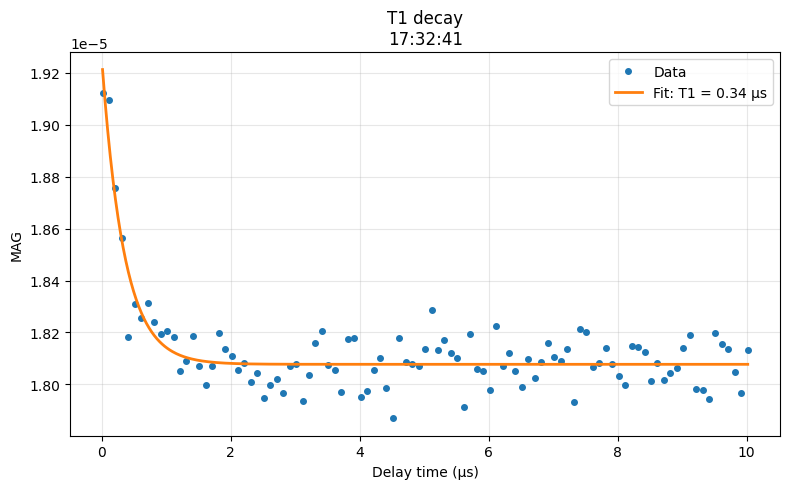


Processing 2/15
17-33-46_QubitT1_versus_time.hdf5

Loading: 17-33-46_QubitT1_versus_time.hdf5
Keys: ['time_delay', 'I', 'Q', 'Magnitude']
Using 'time_delay' as delay-time axis.
Time shape: (101,)
Signal shape: (101,)
Initial guess: T1=0.848 us, A=4.99083e-07, C=1.77265e-05
T1 = 0.361 us
T1 error = 0.026 us
R² = 0.89374


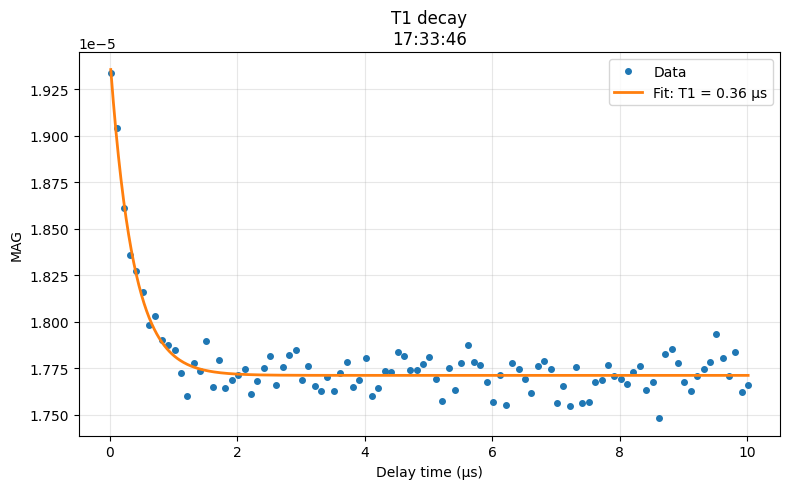


Processing 3/15
17-34-49_QubitT1_versus_time.hdf5

Loading: 17-34-49_QubitT1_versus_time.hdf5
Keys: ['time_delay', 'I', 'Q', 'Magnitude']
Using 'time_delay' as delay-time axis.
Time shape: (101,)
Signal shape: (101,)
Initial guess: T1=1.100 us, A=7.02456e-07, C=1.75186e-05
T1 = 0.505 us
T1 error = 0.025 us
R² = 0.94431


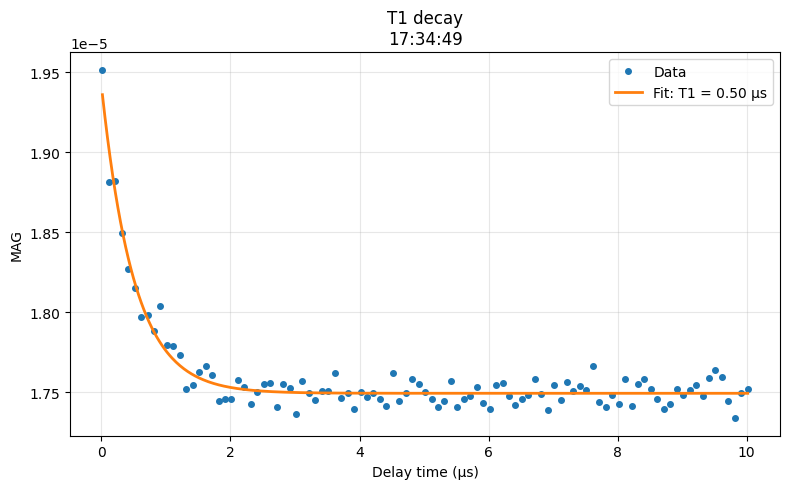


Processing 4/15
17-35-53_QubitT1_versus_time.hdf5

Loading: 17-35-53_QubitT1_versus_time.hdf5
Keys: ['time_delay', 'I', 'Q', 'Magnitude']
Using 'time_delay' as delay-time axis.
Time shape: (101,)
Signal shape: (101,)
Initial guess: T1=1.101 us, A=8.54805e-07, C=1.74029e-05
T1 = 0.541 us
T1 error = 0.020 us
R² = 0.96845


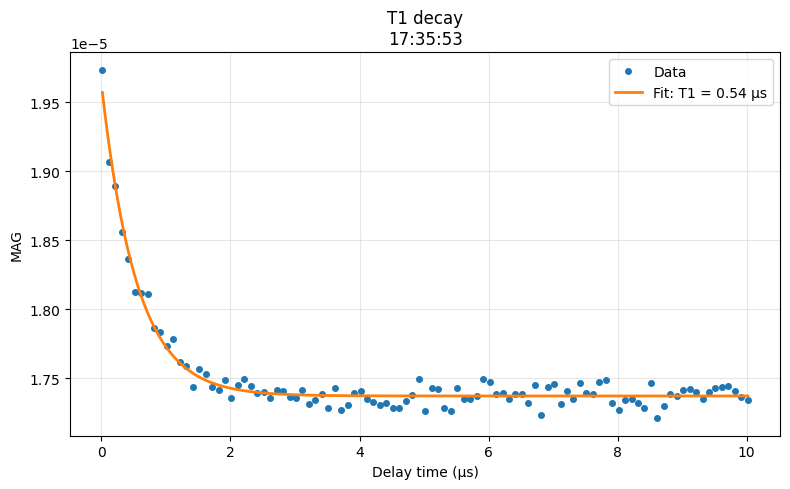


Processing 5/15
17-36-57_QubitT1_versus_time.hdf5

Loading: 17-36-57_QubitT1_versus_time.hdf5
Keys: ['time_delay', 'I', 'Q', 'Magnitude']
Using 'time_delay' as delay-time axis.
Time shape: (101,)
Signal shape: (101,)
Initial guess: T1=0.904 us, A=7.88863e-07, C=1.74898e-05
T1 = 0.453 us
T1 error = 0.022 us
R² = 0.94856


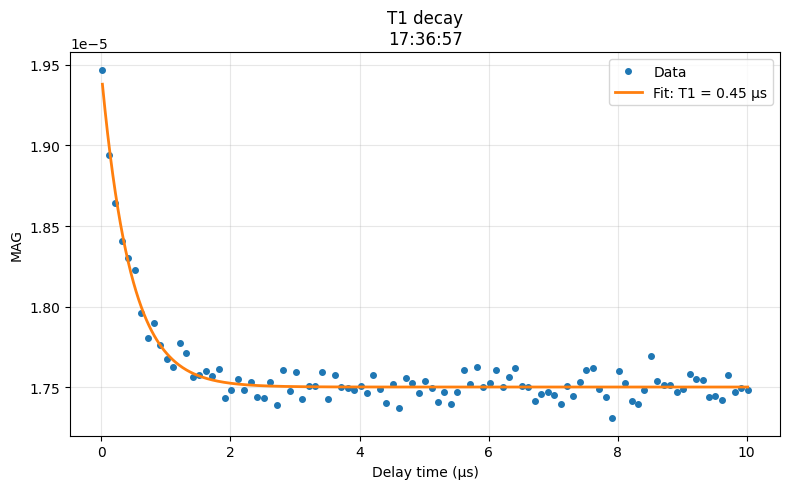


Processing 6/15
17-38-01_QubitT1_versus_time.hdf5

Loading: 17-38-01_QubitT1_versus_time.hdf5
Keys: ['time_delay', 'I', 'Q', 'Magnitude']
Using 'time_delay' as delay-time axis.
Time shape: (101,)
Signal shape: (101,)
Initial guess: T1=0.838 us, A=5.50743e-07, C=1.77932e-05
T1 = 0.397 us
T1 error = 0.027 us
R² = 0.89837


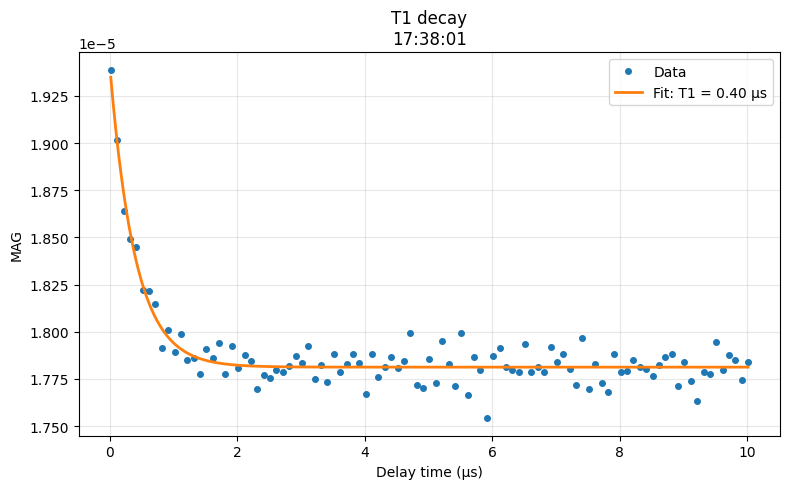


Processing 7/15
17-39-05_QubitT1_versus_time.hdf5

Loading: 17-39-05_QubitT1_versus_time.hdf5
Keys: ['time_delay', 'I', 'Q', 'Magnitude']
Using 'time_delay' as delay-time axis.
Time shape: (101,)
Signal shape: (101,)
Initial guess: T1=0.937 us, A=2.7273e-07, C=1.80195e-05
T1 = 0.352 us
T1 error = 0.032 us
R² = 0.84102


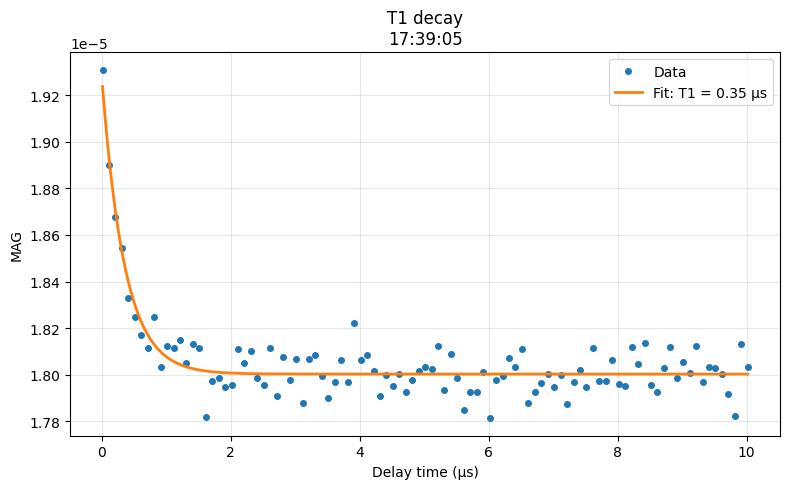


Processing 8/15
17-40-08_QubitT1_versus_time.hdf5

Loading: 17-40-08_QubitT1_versus_time.hdf5
Keys: ['time_delay', 'I', 'Q', 'Magnitude']
Using 'time_delay' as delay-time axis.
Time shape: (101,)
Signal shape: (101,)
Initial guess: T1=1.099 us, A=3.18807e-07, C=1.80912e-05
T1 = 0.302 us
T1 error = 0.030 us
R² = 0.81855


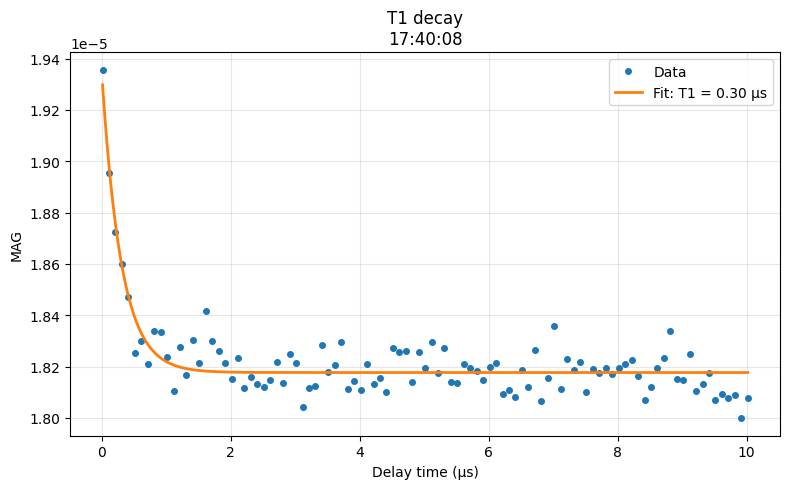


Processing 9/15
17-41-12_QubitT1_versus_time.hdf5

Loading: 17-41-12_QubitT1_versus_time.hdf5
Keys: ['time_delay', 'I', 'Q', 'Magnitude']
Using 'time_delay' as delay-time axis.
Time shape: (101,)
Signal shape: (101,)
Initial guess: T1=1.036 us, A=1.7085e-07, C=1.82516e-05
T1 = 0.268 us
T1 error = 0.033 us
R² = 0.74598


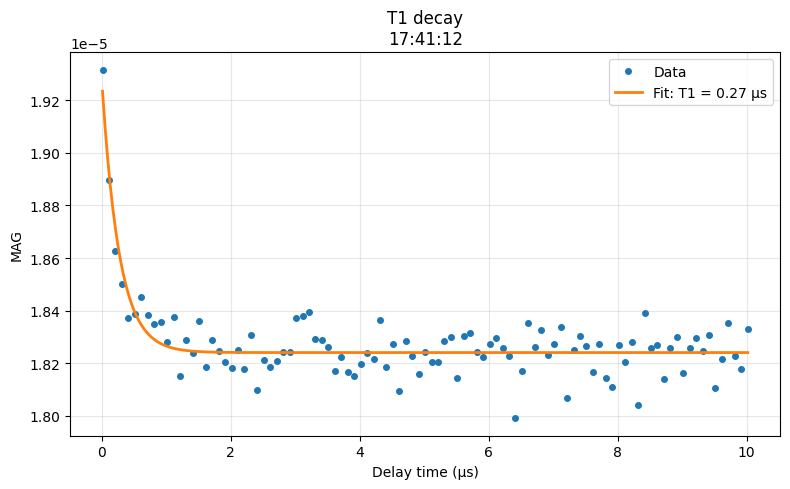


Processing 10/15
17-42-16_QubitT1_versus_time.hdf5

Loading: 17-42-16_QubitT1_versus_time.hdf5
Keys: ['time_delay', 'I', 'Q', 'Magnitude']
Using 'time_delay' as delay-time axis.
Time shape: (101,)
Signal shape: (101,)
Initial guess: T1=0.862 us, A=1.66082e-07, C=1.84402e-05
T1 = 0.253 us
T1 error = 0.031 us
R² = 0.74590


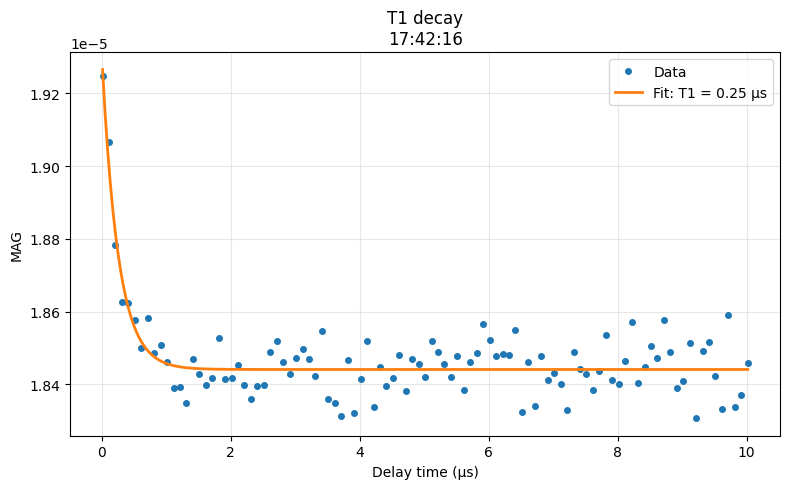


Processing 11/15
17-43-19_QubitT1_versus_time.hdf5

Loading: 17-43-19_QubitT1_versus_time.hdf5
Keys: ['time_delay', 'I', 'Q', 'Magnitude']
Using 'time_delay' as delay-time axis.
Time shape: (101,)
Signal shape: (101,)
Initial guess: T1=0.597 us, A=1.39604e-07, C=1.84249e-05
T1 = 0.251 us
T1 error = 0.032 us
R² = 0.72977


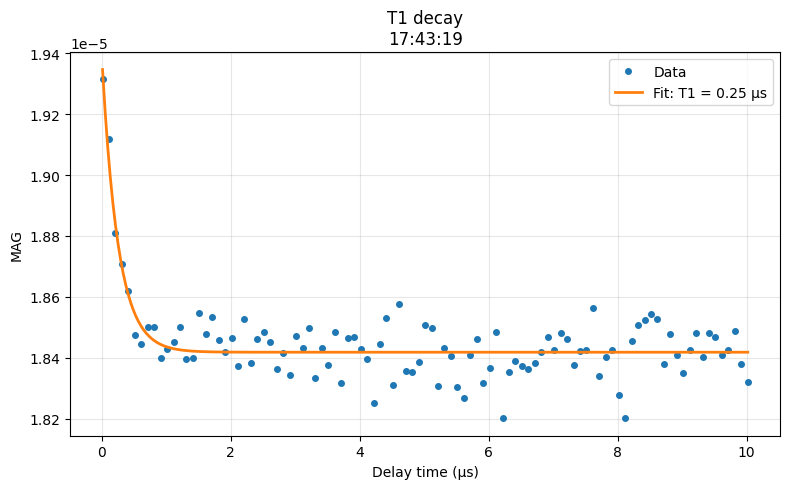


Processing 12/15
17-44-24_QubitT1_versus_time.hdf5

Loading: 17-44-24_QubitT1_versus_time.hdf5
Keys: ['time_delay', 'I', 'Q', 'Magnitude']
Using 'time_delay' as delay-time axis.
Time shape: (101,)
Signal shape: (101,)
Initial guess: T1=0.655 us, A=8.84952e-08, C=1.83741e-05
T1 = 0.237 us
T1 error = 0.033 us
R² = 0.69862


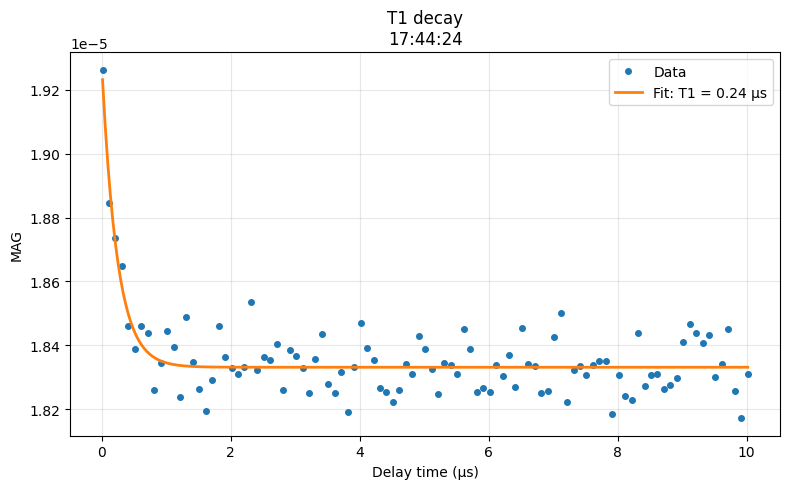


Processing 13/15
17-59-43_QubitT1_versus_time.hdf5

Loading: 17-59-43_QubitT1_versus_time.hdf5
Keys: ['time_delay', 'I', 'Q', 'Magnitude']
Using 'time_delay' as delay-time axis.
Time shape: (81,)
Signal shape: (81,)
Initial guess: T1=0.769 us, A=1.8868e-07, C=1.84016e-05
T1 = 0.276 us
T1 error = 0.032 us
R² = 0.79849


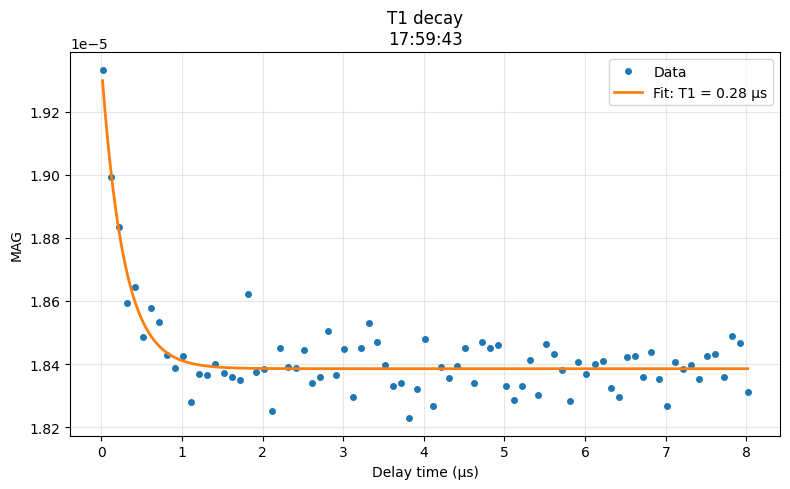


Processing 14/15
18-00-36_QubitT1_versus_time.hdf5

Loading: 18-00-36_QubitT1_versus_time.hdf5
Keys: ['time_delay', 'I', 'Q', 'Magnitude']
Using 'time_delay' as delay-time axis.
Time shape: (81,)
Signal shape: (81,)
Initial guess: T1=1.036 us, A=2.17569e-07, C=1.84109e-05
T1 = 0.280 us
T1 error = 0.041 us
R² = 0.71411


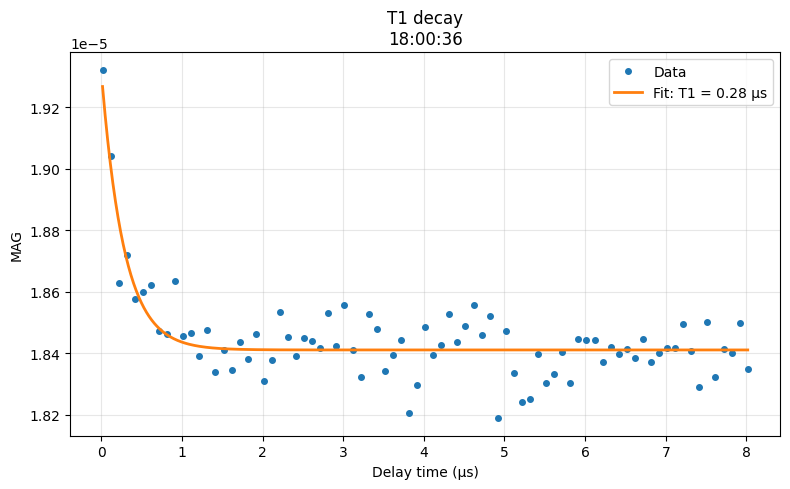


Processing 15/15
18-01-28_QubitT1_versus_time.hdf5

Loading: 18-01-28_QubitT1_versus_time.hdf5
Keys: ['time_delay', 'I', 'Q', 'Magnitude']
Using 'time_delay' as delay-time axis.
Time shape: (81,)
Signal shape: (81,)
Initial guess: T1=0.757 us, A=1.36609e-07, C=1.84161e-05
T1 = 0.224 us
T1 error = 0.026 us
R² = 0.80305


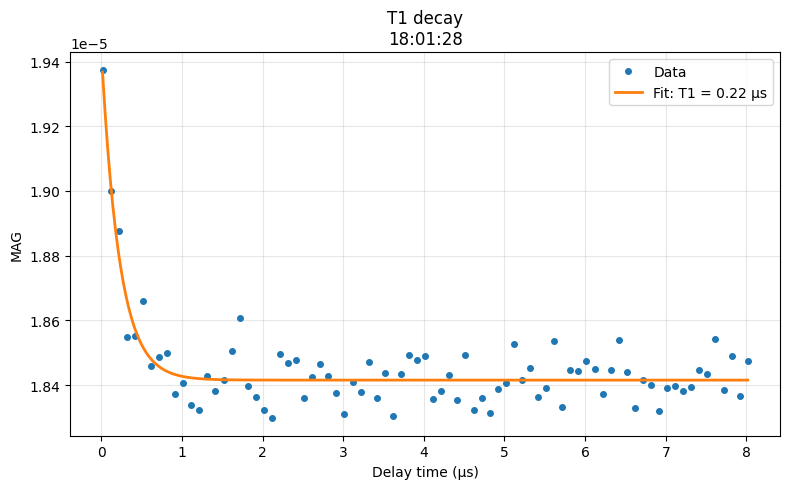



T1 RESULTS
17:32:41   T1 = 0.345 ± 0.036 µs
17:33:46   T1 = 0.361 ± 0.026 µs
17:34:49   T1 = 0.505 ± 0.025 µs
17:35:53   T1 = 0.541 ± 0.020 µs
17:36:57   T1 = 0.453 ± 0.022 µs
17:38:01   T1 = 0.397 ± 0.027 µs
17:39:05   T1 = 0.352 ± 0.032 µs
17:40:08   T1 = 0.302 ± 0.030 µs
17:41:12   T1 = 0.268 ± 0.033 µs
17:42:16   T1 = 0.253 ± 0.031 µs
17:43:19   T1 = 0.251 ± 0.032 µs
17:44:24   T1 = 0.237 ± 0.033 µs
17:59:43   T1 = 0.276 ± 0.032 µs
18:00:36   T1 = 0.280 ± 0.041 µs
18:01:28   T1 = 0.224 ± 0.026 µs


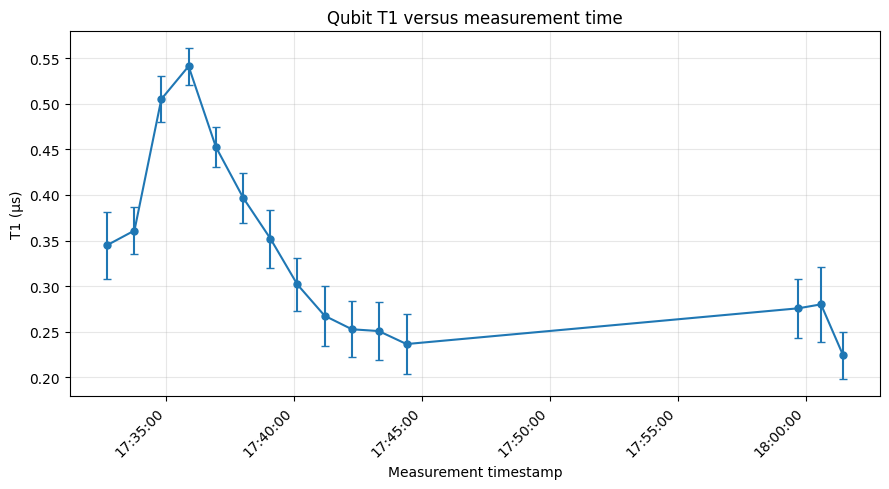


Saved results to:
C:\Users\qcrew\Desktop\Juncheng\victoria\scripts\plot\data_plot_data\QubitT1_versus_time_T1_results.npz


In [2]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import curve_fit
from datetime import datetime

# ==========================================================
# USER SETTINGS
# ==========================================================

build_npz_from_hdf5 = True
load_npz_for_analysis = True

batches = [
    {
        "date": "2026-08-08",
        "folder": r"C:\Users\qcrew\Desktop\Juncheng\victoria\data\2026-08-08",
        "time": ((17, 32), (18, 1)),
    },
]

file_key = "QubitT1_versus_time"

# Choose "I", "Q", or "MAG"
plot_data = "MAG"

# None = automatically find the sweep/time axis
y_key = None

# Usually I/Q/MAG should NOT have their mean subtracted for T1 fitting.
# Set False unless you specifically need it.
subtract_mean = False

x_label = "Delay time"
y_label = "Signal"

show_individual_plots = True

output_folder = (
    r"C:\Users\qcrew\Desktop\Juncheng\victoria"
    r"\scripts\plot\data_plot_data"
)
os.makedirs(output_folder, exist_ok=True)

# ==========================================================
# FIT SETTINGS
# ==========================================================

# Initial fit guesses
# Set to a number in seconds to force a fixed starting guess.
# Keep None to estimate T1 automatically from each trace.
initial_T1 = None
initial_offset = None


def guess_T1(t, y):
    """Robust initial guess for y = A*exp(-t/T1) + C.

    The estimate uses robust medians at the beginning/end of the trace,
    then looks for the first 1/e crossing. If the trace does not reach
    1/e, it falls back to a log-linear estimate and finally to a fraction
    of the measured time span. Works for both upward and downward decays.
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(t) < 3:
        raise ValueError("Need at least 3 points for a T1 guess.")

    # Work relative to the first fitted delay.
    t_rel = t - t[0]
    span = t_rel[-1] - t_rel[0]
    if span <= 0:
        raise ValueError("T1 delay axis must span a positive range.")

    # Median is less sensitive than mean to noisy points/outliers.
    n_edge = max(3, min(10, len(y) // 5))
    y_start = np.median(y[:n_edge])
    C0 = np.median(y[-n_edge:])
    A_start = y_start - C0

    # If start/end medians happen to be too similar, use the full range.
    signal_range = np.ptp(y)
    if abs(A_start) < max(1e-15, 0.05 * signal_range):
        if abs(y[0] - C0) >= abs(y[-1] - C0):
            A_start = y[0] - C0
        else:
            A_start = (np.max(y) - C0) if abs(np.max(y) - C0) >= abs(np.min(y) - C0) else (np.min(y) - C0)

    # Normalize so an ideal decay starts near 1 and approaches 0.
    T1_guess = np.nan
    if abs(A_start) > 1e-15:
        z = (y - C0) / A_start

        # A tiny moving-average smooth suppresses a single noisy point
        # from creating a false 1/e crossing.
        if len(z) >= 7:
            z_search = np.convolve(z, np.ones(3) / 3.0, mode="same")
            z_search[0] = z[0]
            z_search[-1] = z[-1]
        else:
            z_search = z

        target = 1.0 / np.e
        crossing = np.where(
            (z_search[:-1] >= target) & (z_search[1:] <= target)
        )[0]

        if len(crossing) > 0:
            i = crossing[0]
            z1, z2 = z_search[i], z_search[i + 1]
            t1, t2 = t_rel[i], t_rel[i + 1]
            if z2 != z1:
                frac = (target - z1) / (z2 - z1)
                T1_guess = t1 + frac * (t2 - t1)
            else:
                T1_guess = t1

        # If the measured window does not contain the 1/e point, estimate
        # T1 from the slope of log(normalized signal).
        if not np.isfinite(T1_guess) or T1_guess <= 0:
            mask = np.isfinite(z) & (z > 0.05) & (z < 0.95)
            if np.count_nonzero(mask) >= 3:
                slope, _ = np.polyfit(t_rel[mask], np.log(z[mask]), 1)
                if slope < 0:
                    T1_guess = -1.0 / slope

    # Safe fallback if the trace is very flat/noisy.
    if not np.isfinite(T1_guess) or T1_guess <= 0:
        T1_guess = span / 3.0

    # Keep curve_fit's p0 safely inside the allowed T1 interval.
    eps = 1e-6
    T1_guess = np.clip(
        T1_guess,
        T1_min * (1.0 + eps),
        T1_max * (1.0 - eps),
    )

    # exp_decay uses absolute t, so convert the amplitude at t[0] to the
    # model's A parameter. This also works when the first delay is nonzero.
    A0 = A_start * np.exp(t[0] / T1_guess)

    return A0, T1_guess, C0

# Only use points above this fraction of the maximum delay.
# Set to 0 and 1 to use all data.
fit_start_fraction = 0.0
fit_end_fraction = 1.0

# Remove bad fitted T1 values
remove_outliers = True

# Reasonable T1 range
T1_min = 0.1e-6
T1_max = 1e-3


# ==========================================================
# FILE / TIME FUNCTIONS
# ==========================================================

def extract_time(filename):
    """
    Extract HH-MM-SS from filename such as:

    17-32-41_QubitT1_versus_time.hdf5

    Returns:
        (17, 32, 41)
    """
    try:
        name = os.path.basename(filename)
        parts = name.split("-")

        hour = int(parts[0])
        minute = int(parts[1])
        second = int(parts[2].split("_")[0])

        return hour, minute, second

    except Exception:
        return -1, -1, -1


def get_filtered_files(folder, start_time, end_time, file_key):

    if not os.path.exists(folder):
        print(f"Folder not found: {folder}")
        return []

    files = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.endswith(".hdf5") and file_key in f
    ]

    def time_tuple(filename):
        h, m, s = extract_time(filename)
        return h, m, s

    filtered = []

    for f in files:

        h, m, s = time_tuple(f)

        if h < 0:
            continue

        file_time = (h, m)

        if start_time <= file_time <= end_time:
            filtered.append(f)

    return sorted(filtered, key=time_tuple)


# ==========================================================
# INSPECT HDF5 STRUCTURE
# ==========================================================

def print_hdf5_structure(filename):

    print("\n" + "=" * 70)
    print("HDF5 FILE:")
    print(os.path.basename(filename))
    print("=" * 70)

    with h5py.File(filename, "r") as f:

        print("Datasets:")

        for key in f.keys():

            obj = f[key]

            if isinstance(obj, h5py.Dataset):
                print(
                    f"  {key:25s} "
                    f"shape={obj.shape} "
                    f"dtype={obj.dtype}"
                )

    print("=" * 70)


# ==========================================================
# LOAD ONE T1 FILE
# ==========================================================

def load_one_hdf5(filename, y_key=None):

    with h5py.File(filename, "r") as f:

        keys = list(f.keys())

        print(f"\nLoading: {os.path.basename(filename)}")
        print("Keys:", keys)

        # --------------------------------------------------
        # Find delay-time axis
        # --------------------------------------------------

        if y_key is not None:

            if y_key not in f:
                raise KeyError(
                    f"y_key='{y_key}' not found in {filename}"
                )

            time_axis = np.asarray(f[y_key][()])

        else:

            # Try common names first
            possible_time_keys = [
                "time",
                "Time",
                "delay",
                "Delay",
                "tau",
                "Tau",
                "x",
                "X",
                "t",
                "T",
            ]

            found_key = None

            for candidate in possible_time_keys:

                if candidate in f:

                    arr = np.asarray(f[candidate][()])

                    if arr.ndim == 1:
                        found_key = candidate
                        break

            # If not found, look for a 1D dataset that is not I/Q/Magnitude
            if found_key is None:

                excluded = {
                    "I",
                    "Q",
                    "Magnitude",
                    "MAG",
                }

                for key in keys:

                    if key in excluded:
                        continue

                    arr = np.asarray(f[key][()])

                    if arr.ndim == 1:
                        found_key = key
                        break

            if found_key is None:

                raise ValueError(
                    "Could not automatically find the T1 delay-time axis.\n"
                    f"Available keys: {keys}\n"
                    "Set y_key manually."
                )

            time_axis = np.asarray(f[found_key][()])

            print(f"Using '{found_key}' as delay-time axis.")

        # --------------------------------------------------
        # Load signal
        # --------------------------------------------------

        if plot_data == "I":

            if "I" not in f:
                raise KeyError("I dataset not found.")

            signal = np.asarray(f["I"][()])

        elif plot_data == "Q":

            if "Q" not in f:
                raise KeyError("Q dataset not found.")

            signal = np.asarray(f["Q"][()])

        elif plot_data == "MAG":

            if "Magnitude" in f:

                signal = np.asarray(f["Magnitude"][()])

            elif "MAG" in f:

                signal = np.asarray(f["MAG"][()])

            elif "I" in f and "Q" in f:

                I = np.asarray(f["I"][()])
                Q = np.asarray(f["Q"][()])

                signal = np.sqrt(I**2 + Q**2)

            else:

                raise KeyError(
                    "Could not find Magnitude, MAG, or I/Q."
                )

        else:

            raise ValueError(
                "plot_data must be 'I', 'Q', or 'MAG'"
            )

        # --------------------------------------------------
        # Average repeated measurements if necessary
        # --------------------------------------------------

        if signal.ndim > 1:

            # Assume last axis corresponds to delay
            signal = np.mean(signal, axis=0)

        signal = np.asarray(signal).squeeze()

        time_axis = np.asarray(time_axis).squeeze()

        # --------------------------------------------------
        # Check dimensions
        # --------------------------------------------------

        print("Time shape:", time_axis.shape)
        print("Signal shape:", signal.shape)

        if len(time_axis) != len(signal):

            raise ValueError(
                f"Time axis length ({len(time_axis)}) "
                f"does not match signal length ({len(signal)})."
            )

        # --------------------------------------------------
        # Remove NaN / inf
        # --------------------------------------------------

        valid = (
            np.isfinite(time_axis)
            & np.isfinite(signal)
        )

        time_axis = time_axis[valid]
        signal = signal[valid]

        # Sort by delay time
        order = np.argsort(time_axis)

        time_axis = time_axis[order]
        signal = signal[order]

        # --------------------------------------------------
        # Optional mean subtraction
        # --------------------------------------------------

        if subtract_mean:

            signal = signal - np.mean(signal)

        return time_axis, signal


# ==========================================================
# EXPONENTIAL FIT
# ==========================================================

def exp_decay(t, A, T1, C):

    return A * np.exp(-t / T1) + C


def fit_T1(t, signal):

    # ------------------------------------------------------
    # Convert time to seconds if necessary
    # ------------------------------------------------------

    t = np.asarray(t, dtype=float)
    signal = np.asarray(signal, dtype=float)

    # Heuristic:
    # If values look like ns/us, convert appropriately.
    #
    # IMPORTANT:
    # Change this if your HDF5 time unit is known.

    t_max = np.max(np.abs(t))

    if t_max > 1:

        # likely ns
        t_sec = t * 1e-9
        time_unit = "ns"

    elif t_max > 1e-3:

        # likely us
        t_sec = t * 1e-6
        time_unit = "us"

    else:

        # assume seconds
        t_sec = t
        time_unit = "s"

    # ------------------------------------------------------
    # Select fit region
    # ------------------------------------------------------

    t_min = np.min(t_sec)
    t_max_sec = np.max(t_sec)

    fit_mask = (
        (t_sec >= t_min +
         fit_start_fraction * (t_max_sec - t_min))
        &
        (t_sec <= t_min +
         fit_end_fraction * (t_max_sec - t_min))
    )

    t_fit = t_sec[fit_mask]
    y_fit = signal[fit_mask]

    # ------------------------------------------------------
    # Initial guesses
    # ------------------------------------------------------

    A_guess, T1_guess, C_guess = guess_T1(t_fit, y_fit)

    # Optional manual overrides.
    if initial_T1 is not None:
        T1_guess = np.clip(
            float(initial_T1),
            T1_min * (1.0 + 1e-6),
            T1_max * (1.0 - 1e-6),
        )

    if initial_offset is not None:
        C_guess = float(initial_offset)
        A_guess = (y_fit[0] - C_guess) * np.exp(t_fit[0] / T1_guess)

    p0 = [A_guess, T1_guess, C_guess]

    print(
        f"Initial guess: T1={T1_guess * 1e6:.3f} us, "
        f"A={A_guess:.6g}, C={C_guess:.6g}"
    )

    # ------------------------------------------------------
    # Bounds
    # ------------------------------------------------------

    # T1 must be positive
    lower_bounds = [
        -np.inf,
        T1_min,
        -np.inf
    ]

    upper_bounds = [
        np.inf,
        T1_max,
        np.inf
    ]

    # ------------------------------------------------------
    # Fit
    # ------------------------------------------------------

    popt, pcov = curve_fit(
        exp_decay,
        t_fit,
        y_fit,
        p0=p0,
        bounds=(lower_bounds, upper_bounds),
        maxfev=50000
    )

    A_fit, T1_fit, C_fit = popt

    # ------------------------------------------------------
    # Calculate uncertainty
    # ------------------------------------------------------

    try:

        perr = np.sqrt(np.diag(pcov))
        T1_err = perr[1]

    except Exception:

        T1_err = np.nan

    # ------------------------------------------------------
    # R squared
    # ------------------------------------------------------

    y_model = exp_decay(t_fit, *popt)

    ss_res = np.sum((y_fit - y_model) ** 2)

    ss_tot = np.sum(
        (y_fit - np.mean(y_fit)) ** 2
    )

    if ss_tot > 0:

        r_squared = 1 - ss_res / ss_tot

    else:

        r_squared = np.nan

    return (
        t_sec,
        time_unit,
        popt,
        T1_fit,
        T1_err,
        r_squared,
        fit_mask
    )


# ==========================================================
# PROCESS ALL FILES
# ==========================================================

all_files = []

for batch in batches:

    files = get_filtered_files(
        batch["folder"],
        batch["time"][0],
        batch["time"][1],
        file_key
    )

    all_files.extend(files)

if not all_files:

    raise ValueError(
        "No matching QubitT1_versus_time files found."
    )

print("\n" + "=" * 70)
print(f"Found {len(all_files)} T1 files")
print("=" * 70)

for f in all_files:
    print(os.path.basename(f))


# ==========================================================
# FIT EACH FILE
# ==========================================================

measurement_times = []
T1_list = []
T1_err_list = []
R2_list = []
fit_results = []

for file_index, filename in enumerate(all_files):

    print("\n" + "=" * 70)
    print(
        f"Processing {file_index + 1}/{len(all_files)}"
    )
    print(os.path.basename(filename))
    print("=" * 70)

    try:

        # --------------------------------------------------
        # Load
        # --------------------------------------------------

        t, signal = load_one_hdf5(
            filename,
            y_key=y_key
        )

        # --------------------------------------------------
        # Fit
        # --------------------------------------------------

        (
            t_sec,
            time_unit,
            popt,
            T1_fit,
            T1_err,
            r_squared,
            fit_mask
        ) = fit_T1(t, signal)

        A_fit, _, C_fit = popt

        # --------------------------------------------------
        # Measurement timestamp
        # --------------------------------------------------

        h, m, s = extract_time(filename)

        measurement_datetime = datetime(
            int(batches[0]["date"][0:4]),
            int(batches[0]["date"][5:7]),
            int(batches[0]["date"][8:10]),
            h,
            m,
            s
        )

        measurement_times.append(
            measurement_datetime
        )

        T1_list.append(T1_fit)
        T1_err_list.append(T1_err)
        R2_list.append(r_squared)

        fit_results.append({
            "filename": filename,
            "datetime": measurement_datetime,
            "T1": T1_fit,
            "T1_err": T1_err,
            "R2": r_squared,
            "A": A_fit,
            "C": C_fit,
        })

        print(
            f"T1 = {T1_fit * 1e6:.3f} us"
        )

        print(
            f"T1 error = {T1_err * 1e6:.3f} us"
        )

        print(
            f"R² = {r_squared:.5f}"
        )

        # ==================================================
        # PLOT INDIVIDUAL T1 FIT
        # ==================================================

        if show_individual_plots:

            plt.figure(figsize=(8, 5))

            # Plot raw data
            plt.plot(
                t_sec * 1e6,
                signal,
                "o",
                markersize=4,
                label="Data"
            )

            # Smooth fit curve
            t_smooth = np.linspace(
                np.min(t_sec),
                np.max(t_sec),
                500
            )

            y_smooth = exp_decay(
                t_smooth,
                *popt
            )

            plt.plot(
                t_smooth * 1e6,
                y_smooth,
                "-",
                linewidth=2,
                label=(
                    f"Fit: T1 = "
                    f"{T1_fit * 1e6:.2f} µs"
                )
            )

            plt.xlabel("Delay time (µs)")
            plt.ylabel(plot_data)

            plt.title(
                f"T1 decay\n"
                f"{measurement_datetime.strftime('%H:%M:%S')}"
            )

            plt.grid(alpha=0.3)

            plt.legend()

            plt.tight_layout()

            plt.show()

    except Exception as e:

        print(
            f"ERROR processing "
            f"{os.path.basename(filename)}:"
        )

        print(e)


# ==========================================================
# CONVERT TO ARRAYS
# ==========================================================

measurement_times = np.array(
    measurement_times,
    dtype=object
)

T1_array = np.array(T1_list)
T1_err_array = np.array(T1_err_list)
R2_array = np.array(R2_list)


# ==========================================================
# REMOVE OUTLIERS
# ==========================================================

valid = np.isfinite(T1_array)

if remove_outliers:

    valid &= (
        (T1_array >= T1_min)
        &
        (T1_array <= T1_max)
    )

    # Optional R² requirement
    valid &= R2_array > 0

measurement_times_valid = measurement_times[valid]
T1_valid = T1_array[valid]
T1_err_valid = T1_err_array[valid]
R2_valid = R2_array[valid]


# ==========================================================
# SORT BY MEASUREMENT TIME
# ==========================================================

order = np.argsort(
    measurement_times_valid
)

measurement_times_valid = (
    measurement_times_valid[order]
)

T1_valid = T1_valid[order]

T1_err_valid = T1_err_valid[order]

R2_valid = R2_valid[order]


# ==========================================================
# PRINT RESULTS
# ==========================================================

print("\n")
print("=" * 70)
print("T1 RESULTS")
print("=" * 70)

for tstamp, t1, err in zip(
    measurement_times_valid,
    T1_valid,
    T1_err_valid
):

    print(
        f"{tstamp.strftime('%H:%M:%S')}   "
        f"T1 = {t1 * 1e6:.3f} ± "
        f"{err * 1e6:.3f} µs"
    )


# ==========================================================
# PLOT T1 VS MEASUREMENT TIME
# ==========================================================

if len(T1_valid) > 0:

    # Keep elapsed time for saving to NPZ.
    time_zero = measurement_times_valid[0]

    elapsed_minutes = np.array([
        (t - time_zero).total_seconds() / 60
        for t in measurement_times_valid
    ])

    # Plot using the actual timestamp parsed from each HDF5 filename.
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.errorbar(
        measurement_times_valid,
        T1_valid * 1e6,
        yerr=T1_err_valid * 1e6,
        fmt="o-",
        capsize=3,
        markersize=5
    )

    ax.set_xlabel("Measurement timestamp")
    ax.set_ylabel("T1 (µs)")
    ax.set_title("Qubit T1 versus measurement time")

    # Show the filename timestamp as HH:MM:SS on the x axis.
    locator = mdates.AutoDateLocator(minticks=4, maxticks=10)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))

    fig.autofmt_xdate(rotation=45, ha="right")

    ax.grid(alpha=0.3)

    fig.tight_layout()

    plt.show()


# ==========================================================
# SAVE FIT RESULTS
# ==========================================================

result_npz = os.path.join(
    output_folder,
    f"{file_key}_T1_results.npz"
)

np.savez_compressed(
    result_npz,

    measurement_times=np.array(
        [
            t.strftime("%Y-%m-%d %H:%M:%S")
            for t in measurement_times_valid
        ],
        dtype=str
    ),

    elapsed_minutes=elapsed_minutes,

    T1_seconds=T1_valid,

    T1_us=T1_valid * 1e6,

    T1_error_seconds=T1_err_valid,

    T1_error_us=T1_err_valid * 1e6,

    R_squared=R2_valid,

    filenames=np.array(
        [
            r["filename"]
            for r in fit_results
            if r["datetime"] in measurement_times_valid
        ],
        dtype=str
    )
)

print("\nSaved results to:")
print(result_npz)

In [3]:
# ==========================================================
# 1D CUT: PLOT SPECTRUM FOR EACH FLUX/CURRENT
# ==========================================================

if load_npz_for_analysis:

    data = np.load(npz_path, allow_pickle=True)

    x_values = data["current"]          # A
    y_values = data["cav_if"] + lo      # Hz
    data_2d = data[plot_data]           # shape: (number of currents, number of freq points)

    # Convert frequency to GHz
    freq_GHz = y_values / 1e9

    # Convert current to mA
    current_mA = x_values * 1e3

    # ------------------------------------------------------
    # Plot all 1D cuts
    # ------------------------------------------------------
    plt.figure(figsize=(10, 6))

    for i, current in enumerate(current_mA):
        plt.plot(
            freq_GHz,
            data_2d[i],
            label=f"{current:.1f} mA"
        )

        plt.xlabel("Cavity Frequency (GHz)")
        plt.ylabel(plot_data)
        plt.title(f"{plot_data} spectra for each flux/current")
        plt.grid(alpha=0.3)
        plt.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            fontsize=8
        )
        plt.tight_layout()
        plt.show()

NameError: name 'npz_path' is not defined

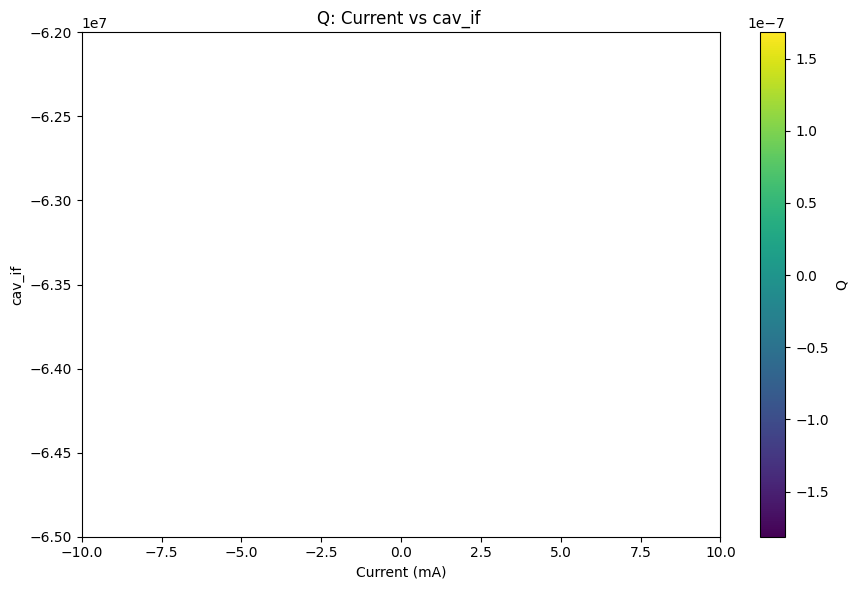

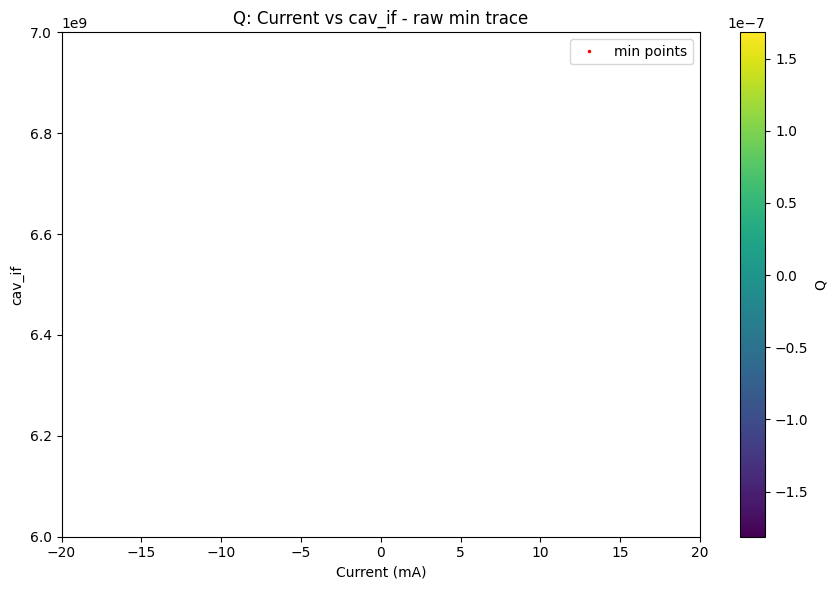

In [ ]:
if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)
    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Step 3: Raw 2D Mesh Plot
    base_mesh_plot(x_values, y_values, data_2d)

    plt.xlim(-10, 10)       # x-axis: -20 to +20 mA
    plt.ylim(-65e6, -62e6)  # y-axis: 6 to 7 GHz

    plt.show()

    # Step 4 & 5: Find Min/Max Trace & Plot Overlay
    idx = np.argmin(data_2d, axis=1) if find_mode == "min" else np.argmax(data_2d, axis=1)
    trace_y = y_values[idx]
    trace_val = data_2d[np.arange(data_2d.shape[0]), idx]

    base_mesh_plot(x_values, y_values, data_2d, f"- raw {find_mode} trace")

    plt.plot(
        x_values * 1e3 if plot_current_in_mA else x_values,
        trace_y,
        "r.",
        markersize=3,
        label=f"{find_mode} points"
    )

    plt.xlim(-20, 20)
    plt.ylim(6.0e9, 7.0e9)

    plt.legend()
    plt.show()

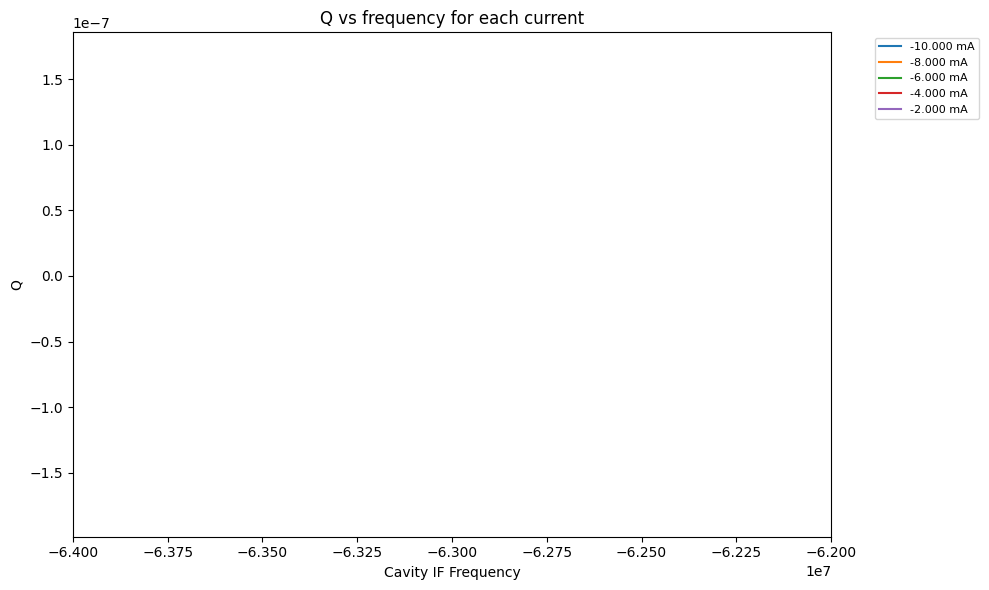

In [ ]:
if load_npz_for_analysis:
    data = np.load(npz_path, allow_pickle=True)

    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    # Convert current to mA for labels
    currents_mA = x_values * 1e3

    # Plot 1D trace for each current
    plt.figure(figsize=(10, 6))

    for i, current in enumerate(currents_mA):
        plt.plot(
            y_values,
            data_2d[i, :],
            label=f"{current:.3f} mA"
        )

    plt.xlabel("Cavity IF Frequency")
    plt.ylabel(plot_data)
    plt.title(f"{plot_data} vs frequency for each current")

    # Optional limits
    plt.xlim(-64e6, -62e6)

    plt.legend(
        bbox_to_anchor=(1.05, 1),
        loc="upper left",
        fontsize=8
    )

    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

if load_npz_for_analysis:

    data = np.load(npz_path, allow_pickle=True)

    x_values = data["current"]
    y_values = data["cav_if"] if "cav_if" in data.keys() else data["y_values"]
    data_2d = data[plot_data]

    currents_mA = x_values * 1e3

    # ==========================================================
    # Gaussian function
    # ==========================================================
    def gaussian(x, amplitude, center, sigma, offset):
        return (
            offset
            + amplitude * np.exp(
                -(x - center)**2 / (2 * sigma**2)
            )
        )

    # ==========================================================
    # Store fitted resonance frequencies
    # ==========================================================
    fit_freq = []

    # ==========================================================
    # FIT EACH CURRENT SEPARATELY
    # ==========================================================
    for i, current in enumerate(currents_mA):

        x = y_values
        y = data_2d[i, :]

        # Fit range
        mask = (x >= -64e6) & (x <= -62e6)

        x_fit = x[mask]
        y_fit = y[mask]

        # Initial guesses
        center_guess = x_fit[np.argmin(y_fit)]
        offset_guess = np.max(y_fit)
        amplitude_guess = np.min(y_fit) - offset_guess
        sigma_guess = 0.2e6

        p0 = [
            amplitude_guess,
            center_guess,
            sigma_guess,
            offset_guess
        ]

        try:

            popt, pcov = curve_fit(
                gaussian,
                x_fit,
                y_fit,
                p0=p0,
                maxfev=10000
            )

            amplitude, center, sigma, offset = popt

            fit_freq.append(center)

            # ==================================================
            # Plot THIS CURRENT ONLY
            # ==================================================

            x_smooth = np.linspace(
                x_fit.min(),
                x_fit.max(),
                500
            )

            y_smooth = gaussian(
                x_smooth,
                *popt
            )

            plt.figure(figsize=(8, 5))

            # Measured data
            plt.plot(
                x_fit / 1e6,
                y_fit,
                "o",
                markersize=4,
                label="Measured"
            )

            # Gaussian fit
            plt.plot(
                x_smooth / 1e6,
                y_smooth,
                "-",
                linewidth=2,
                label="Gaussian fit"
            )

            # Fitted center
            plt.axvline(
                center / 1e6,
                linestyle="--",
                label=f"Center = {center/1e6:.6f} MHz"
            )

            plt.xlabel("Cavity IF frequency (MHz)")
            plt.ylabel(plot_data)

            plt.title(
                f"Gaussian fit — I = {current:.3f} mA"
            )

            plt.xlim(-64, -62)

            plt.grid(True)
            plt.legend()

            plt.tight_layout()
            plt.show()

        except RuntimeError:

            print(
                f"Fit failed at I = {current:.3f} mA"
            )

            fit_freq.append(np.nan)

    fit_freq = np.array(fit_freq)

    # ==========================================================
    # Resonance frequency vs current
    # ==========================================================

    plt.figure(figsize=(8, 5))

    plt.plot(
        currents_mA,
        fit_freq / 1e6,
        "o-",
        markersize=5
    )

    plt.xlabel("Current (mA)")
    plt.ylabel("Fitted resonance frequency (MHz)")

    plt.title("Resonance frequency vs current")

    plt.grid(True)

    plt.tight_layout()
    plt.show()

ValueError: attempt to get argmin of an empty sequence